In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt

In [2]:
#zachlanne rozwiazanie
def greedy_coloring(G, population, k):
    colored = {}
    uncolored = 0
    
    for p in population:
        used_colors = set()
        
        for u in G.neighbors(p):
            if u in colored:
                used_colors.add(colored[u])
                
        for color in range(k):
            if color not in used_colors:
                colored[p] = color
                break
        else:
            uncolored += 1
                
    return colored, uncolored

In [3]:
#krzyzowanie
def crossover(p1, p2):
    n = len(p1)
    a, b = random.sample(range(n), 2)
    child = [None] * n
    child[a:b] = p1[a:b]
    fill = [x for x in p2 if x not in child]
    idx = 0
    
    for i in range(n):
        if child[i] == None:
            child[i] = fill[idx]
            idx +=1
            
    return child

In [4]:
#mutacja scramble
def mutation(per, p=0.25):
    if random.random() < p:
        a, b = sorted(random.sample(range(len(per)), 2))
        sset = per[a:b]
        random.shuffle(sset)
        per[a:b] = sset
        
    return per

In [5]:
#mutacja przez inwersje
def inv_mutation(per, p=0.25):
    if random.random() < p:
        a,b = sorted(random.sample(range(len(per)), 2))
        per[a:b] = reversed(per[a:b])
                            
    return per

In [6]:
#algorytm
def coloring_algorithm(G, k, pop_size = 200, generations = 300):
    nodes = list(G.nodes())
    n = len(nodes)
    population = [random.sample(nodes, n) for _ in range(pop_size)]
    
    for gen in range(generations):
        score = []
        for i in population:
            _, fitness = greedy_coloring(G, i, k)
            score.append((i, fitness))
            
        score.sort(key=lambda item: item[1])
        best_fitness = score[0][1]
        
        if best_fitness == 0:
            print(f"zneleziono najlepsze rozwiazanie w {gen} generacji")
            return score[0]

        new_population = [score[i][0] for i in range(pop_size // 10)]

        while len(new_population) < pop_size:
            p1, p2= random.sample(population[:100], 2)
            child = crossover(p1, p2)
            child = mutation(child)
            child = inv_mutation(child)
            new_population.append(child)

        population = new_population

    print(f"nie znaleziono najlepszego rozwiazania")
    return score[0]

 nie znaleziono najlepszego rozwiazania
Liczba niepokolorowanych: 2
Kolorowanie: {7: 0, 5: 0, 2: 0, 11: 1, 14: 0, 17: 2, 18: 2, 1: 1, 13: 1, 16: 0, 10: 2, 12: 2, 9: 2, 8: 1, 15: 0, 19: 0, 3: 2, 4: 0}


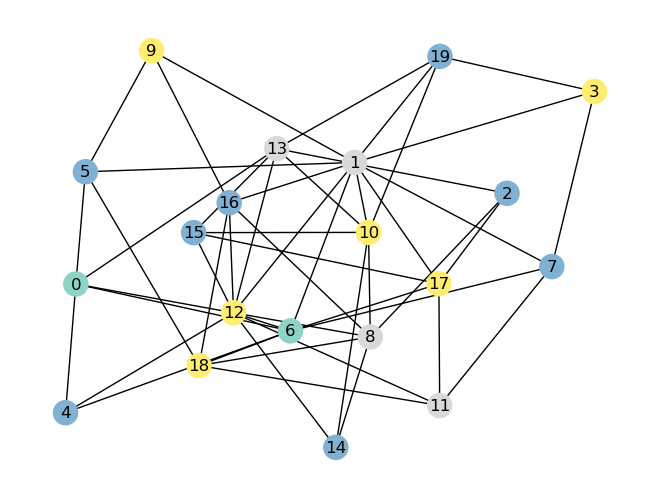

In [45]:
G = nx.gnm_random_graph(20, 50)
k = 3
best_perm, fitness = coloring_algorithm(G, k)
coloring, _ = greedy_coloring(G, best_perm, k)

print("Liczba niepokolorowanych:", fitness)
print("Kolorowanie:", coloring)

nx.draw(G, with_labels=True,
        node_color=[coloring.get(v, -1) for v in G],
        cmap=plt.cm.Set3)
plt.show()